In [35]:
import stim

from spiderstate.cat_at_origin import *
from spidercat.draw import draw_forest_on_graph
from spiderstate.utils import load_qecc

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


[[0 0 1 0 1 0 0 1 1]
 [0 0 1 0 0 1 0 0 0]
 [0 0 0 1 0 0 1 0 0]
 [1 1 0 0 1 0 1 0 0]]

[[1 0 0 0 1 0 0 0 1]]

[[0 0 1 0 1 0 1 0 0]]
RX 0
R 1 2
RX 3
R 4
RX 5
R 6
RX 7
R 8 9
CX 0 9
R 10
CX 7 10 0 1 5 2 3 6 7 8 10 2 9 6 10 4 7 10
M 10
CX 9 4 0 9
M 9
DETECTOR rec[-2]
DETECTOR rec[-1]


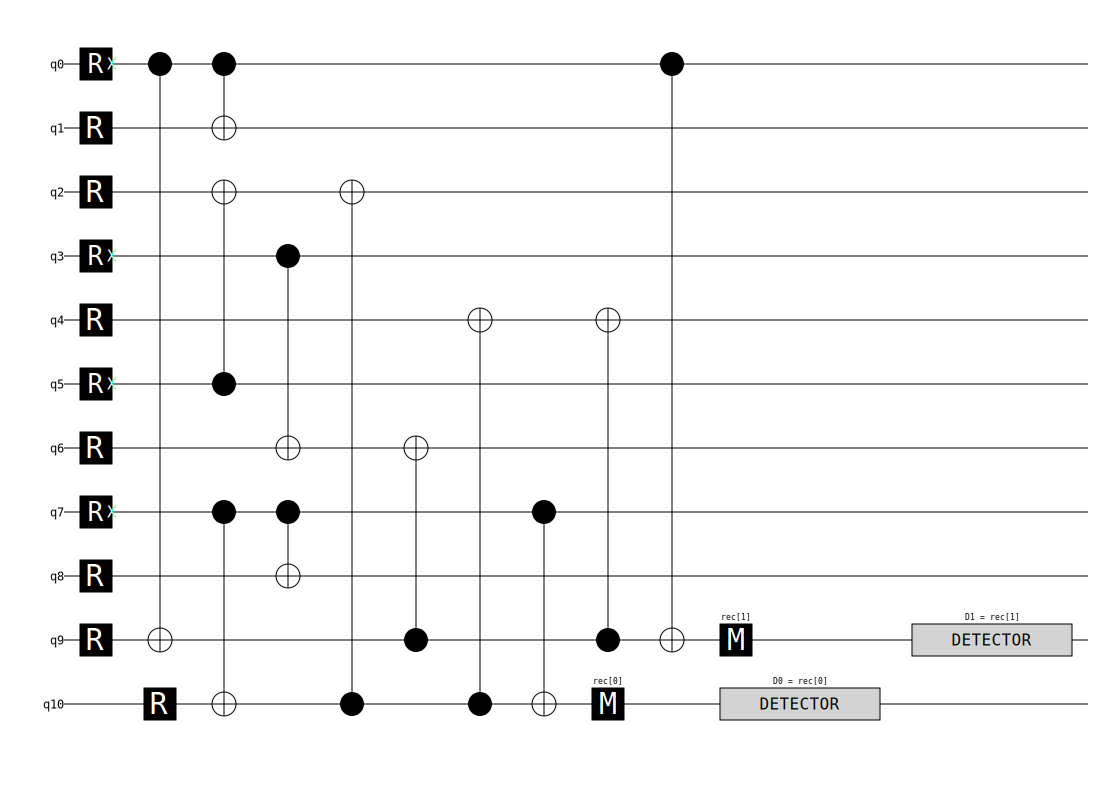

In [38]:
is_self_dual, H_x, H_z, L_x, L_z, d = load_qecc("9_1_3", "FAO")
t = d // 2

row_M, final_M, col_ops = optimize_fault_tolerant_matrix(H_z, t=t, max_col_ops=10, max_basis_tries=10_000)
print(row_M, L_x, L_z, sep="\n\n")

circ = cat_at_origin(row_M, d)
print(circ)
circ.diagram('timeline-svg')

In [39]:
N = 10

circuit = circ.copy()
circuit.append("M", range(H_x.shape[1]))
for i, H in enumerate(H_x):
    qubit_indices = np.where(H == 1)[0]
    record_targets = [stim.target_rec(i - H_x.shape[1]) for i in qubit_indices]
    circuit.append("DETECTOR", record_targets)
for i, L in enumerate(L_x):
    qubit_indices = np.where(L == 1)[0]
    record_targets = [stim.target_rec(i - H_x.shape[1]) for i in qubit_indices]
    circuit.append("OBSERVABLE_INCLUDE", record_targets, i)
circuit.diagram('timeline-svg')
syndrome, observables = circuit.compile_detector_sampler().sample(N, separate_observables=True)

for i in range(N):
    print(f"Flags = {syndrome[i,:-H_x.shape[0]].astype(int)};\t\tSyndrome = {syndrome[i,-H_x.shape[0]:].astype(int)};\t\tLogicals = {observables[i].astype(int)}")

Flags = [0 0];		Syndrome = [0 0 0 0];		Logicals = [0]
Flags = [0 0];		Syndrome = [0 0 0 0];		Logicals = [0]
Flags = [0 0];		Syndrome = [0 0 0 0];		Logicals = [0]
Flags = [0 0];		Syndrome = [0 0 0 0];		Logicals = [0]
Flags = [0 0];		Syndrome = [0 0 0 0];		Logicals = [0]
Flags = [0 0];		Syndrome = [0 0 0 0];		Logicals = [0]
Flags = [0 0];		Syndrome = [0 0 0 0];		Logicals = [0]
Flags = [0 0];		Syndrome = [0 0 0 0];		Logicals = [0]
Flags = [0 0];		Syndrome = [0 0 0 0];		Logicals = [0]
Flags = [0 0];		Syndrome = [0 0 0 0];		Logicals = [0]


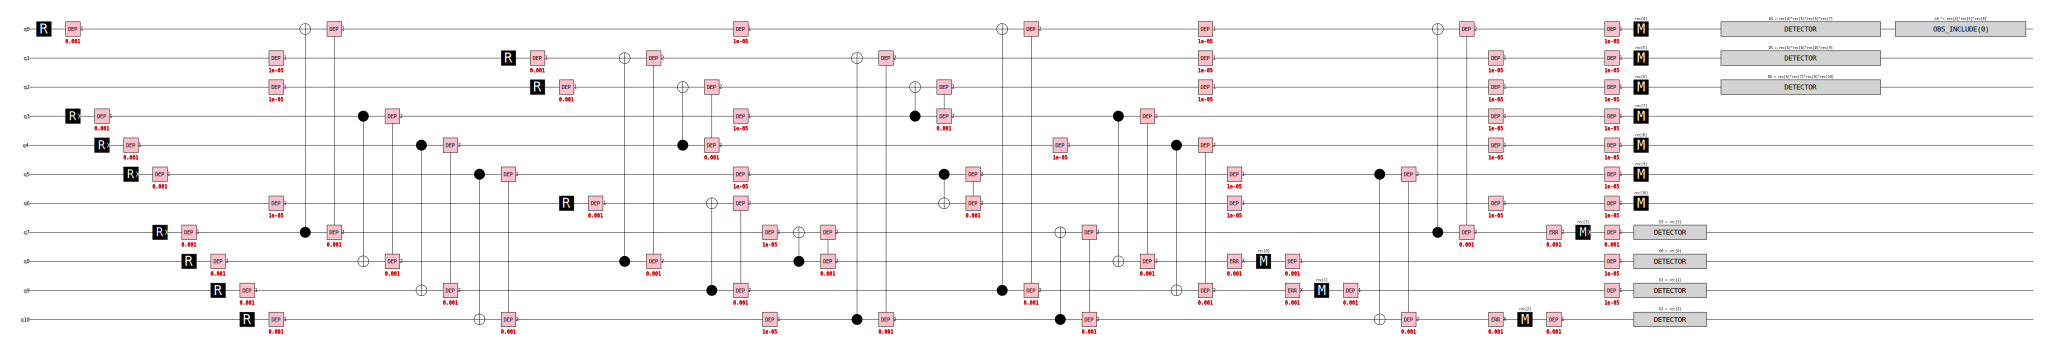

In [40]:
stim.Circuit("""
R 0
DEPOLARIZE1(0.001) 0
RX 3
DEPOLARIZE1(0.001) 3
RX 4
DEPOLARIZE1(0.001) 4
RX 5
DEPOLARIZE1(0.001) 5
RX 7
DEPOLARIZE1(0.001) 7
R 8
DEPOLARIZE1(0.001) 8
R 9
DEPOLARIZE1(0.001) 9
R 10
DEPOLARIZE1(0.001) 10
DEPOLARIZE1(1e-05) 1 2 6
CX 7 0
DEPOLARIZE2(0.001) 7 0
CX 3 8
DEPOLARIZE2(0.001) 3 8
CX 4 9
DEPOLARIZE2(0.001) 4 9
CX 5 10
DEPOLARIZE2(0.001) 5 10
R 1
DEPOLARIZE1(0.001) 1
R 2
DEPOLARIZE1(0.001) 2
R 6
DEPOLARIZE1(0.001) 6
DEPOLARIZE1(1e-05)
CX 8 1
DEPOLARIZE2(0.001) 8 1
CX 4 2
DEPOLARIZE2(0.001) 4 2
CX 9 6
DEPOLARIZE2(0.001) 9 6
DEPOLARIZE1(1e-05) 0 3 5 7 10
CX 8 7
DEPOLARIZE2(0.001) 8 7
CX 10 1
DEPOLARIZE2(0.001) 10 1
CX 3 2
DEPOLARIZE2(0.001) 3 2
CX 5 6
DEPOLARIZE2(0.001) 5 6
CX 9 0
DEPOLARIZE2(0.001) 9 0
DEPOLARIZE1(1e-05) 4
CX 10 7
DEPOLARIZE2(0.001) 10 7
CX 3 8
DEPOLARIZE2(0.001) 3 8
CX 4 9
DEPOLARIZE2(0.001) 4 9
DEPOLARIZE1(1e-05) 0 1 2 5 6
X_ERROR(0.001) 8
M 8
DEPOLARIZE1(0.001) 8
X_ERROR(0.001) 9
M 9
DEPOLARIZE1(0.001) 9
CX 5 10
DEPOLARIZE2(0.001) 5 10
CX 7 0
DEPOLARIZE2(0.001) 7 0
DEPOLARIZE1(1e-05) 1 2 3 4 6
X_ERROR(0.001) 10
M 10
DEPOLARIZE1(0.001) 10
Z_ERROR(0.001) 7
MX 7
DEPOLARIZE1(0.001) 7
DEPOLARIZE1(1e-05) 0 1 2 3 4 5 6 8 9
DETECTOR rec[-4]
DETECTOR rec[-3]
DETECTOR rec[-2]
DETECTOR rec[-1]
M 0 1 2 3 4 5 6
DETECTOR rec[-7] rec[-6] rec[-5] rec[-4]
DETECTOR rec[-6] rec[-5] rec[-3] rec[-2]
DETECTOR rec[-5] rec[-4] rec[-2] rec[-1]
OBSERVABLE_INCLUDE(0) rec[-7] rec[-6] rec[-3]
""").diagram('timeline-svg')